In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

2026-06-13 16:41:52.420970: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781368912.717788      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781368912.804075      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781368913.497636      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781368913.497695      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781368913.497699      58 computation_placer.cc:177] computation placer alr

[]


2026-06-13 16:42:11.102537: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [12]:
import pandas as pd
import numpy as np

#visualiation
import matplotlib.pyplot as plt
import seaborn as sns

import nltk

import warnings 
warnings.filterwarnings('ignore')

print("Libraries imported successfulyy")

Libraries imported successfulyy


In [13]:
df=pd.read_csv('/kaggle/input/datasets/amgothvijaykumar/dataset-emotions-from-text/main.csv')
df.head()

,text,label
0,Layin n bed with a headache ughhhh...waitin o...,sadness
1,Funeral ceremony...gloomy friday...,sadness
2,@dannycastillo We want to trade with someone w...,neutral
3,"I should be sleep, but im not! thinking about ...",sadness
4,@charviray Charlene my love. I miss you,sadness


In [14]:
# : BASIC DATASET INFO

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (69298, 2)

Column Names:
Index(['text', 'label'], dtype='object')

Missing Values:
text     0
label    0
dtype: int64

Duplicate Rows: 148


In [17]:
# Removing duplicates 

print("Before removing duplicates: ",df.shape)
df=df.drop_duplicates()
print("After removing duplicates: ",df.shape)

Before removing duplicates:  (69150, 2)
After removing duplicates:  (69150, 2)


In [16]:
# Download NLTK DATA

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


True

In [18]:
#NLP utilities
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words=set(stopwords.words('english'))

# Important words to preserve
important_words = {
    'not',
    'no',
    'nor',
    'never',
    'very',
    'too',
    'so',
    'really',
    'just',
    'still',
    'again',
    'only'
}

# Remove them from stopwords
stop_words = stop_words - important_words

lemmatizer=WordNetLemmatizer()

In [21]:
#Text cleaning fun
def clean_text(text):
    
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove mentions (@username)
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags
    text = re.sub(r'#\w+', '', text)

    # Remove punctuation, numbers, special chars
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = text.split()

    # Stopword removal + Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(words)

In [22]:
#Applying clean_text

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()

,text,clean_text
0,Layin n bed with a headache ughhhh...waitin o...,layin n bed headache ughhhh waitin call
1,Funeral ceremony...gloomy friday...,funeral ceremony gloomy friday
2,@dannycastillo We want to trade with someone w...,want trade someone houston ticket no one
3,"I should be sleep, but im not! thinking about ...",sleep im not thinking old friend want married ...
4,@charviray Charlene my love. I miss you,charlene love miss


In [23]:
#removing emplty rows
df = df[df['clean_text'].str.strip() != '']

print("Final Shape:", df.shape)

Final Shape: (68930, 3)


In [24]:
empty_rows_count = df.isna().all(axis=1).sum()
print("Empty rows count:", empty_rows_count)

Empty rows count: 0


In [25]:
print(df['label'].unique()) #unique labels
#labels count
label_counts = df['label'].value_counts()

print(label_counts)

['sadness' 'neutral' 'surprise' 'love' 'anger' 'fear' 'joy']
label
neutral     24413
sadness     13015
joy         10065
love         7326
anger        6562
surprise     3920
fear         3629
Name: count, dtype: int64


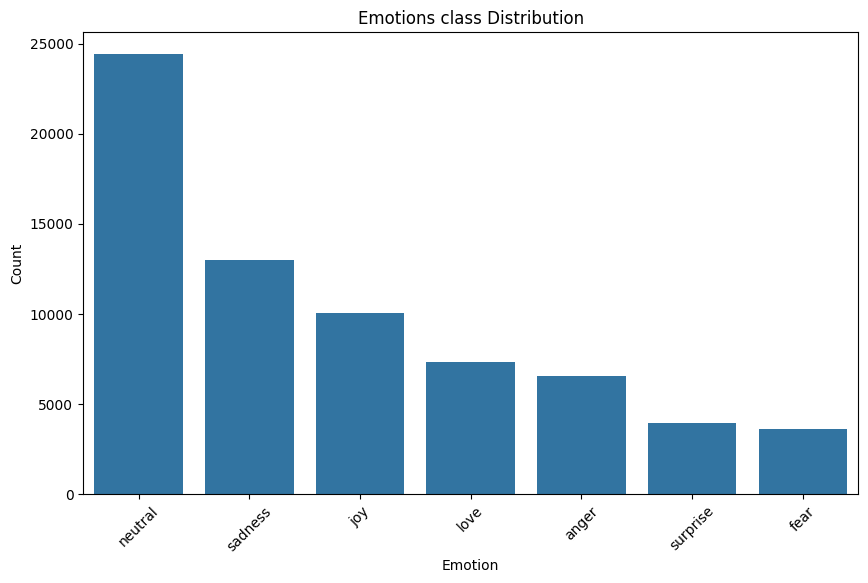

In [26]:
# CLASS DISTRIBUTION PLOT
plt.figure(figsize=(10,6))
sns.barplot(
    x=label_counts.index,
    y=label_counts.values
)

plt.title('Emotions class Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

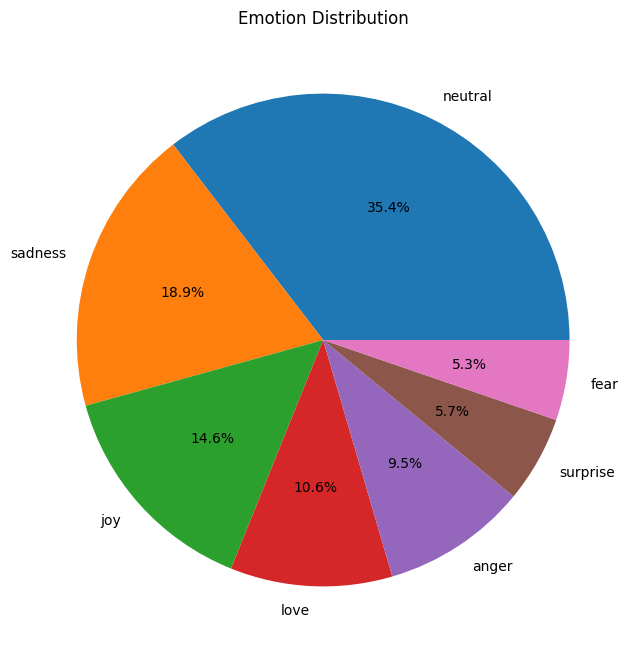

In [27]:
# PIE CHART

plt.figure(figsize=(8,8))

plt.pie(
    label_counts.values,
    labels=label_counts.index,
    autopct='%1.1f%%'
)

plt.title("Emotion Distribution")

plt.show()

In [28]:

# TEXT LENGTH ANALYSIS

df['text_length'] = df['clean_text'].apply(lambda x: len(x.split()))

df['text_length'].describe()

count    68930.000000
mean         7.764703
std          4.546000
min          1.000000
25%          4.000000
50%          7.000000
75%         10.000000
max         40.000000
Name: text_length, dtype: float64

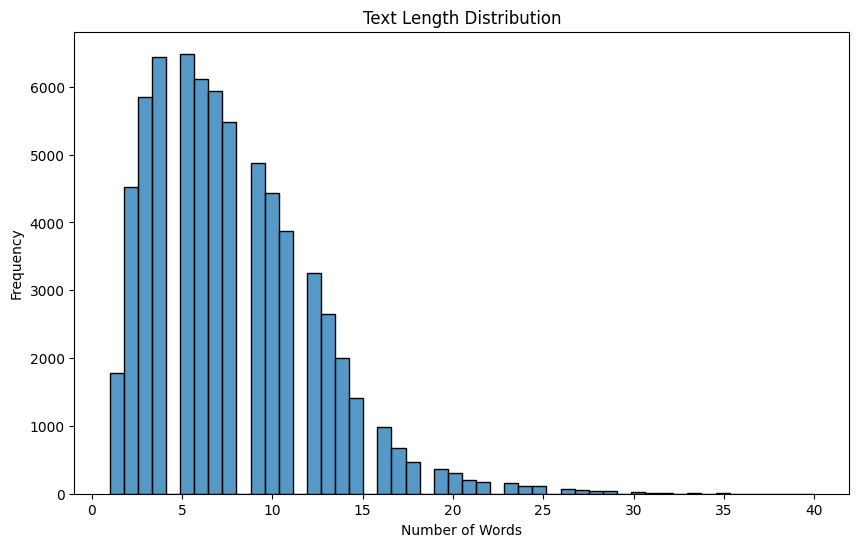

In [29]:
# TEXT LENGTH DISTRIBUTION

plt.figure(figsize=(10,6))

sns.histplot(df['text_length'], bins=50)

plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

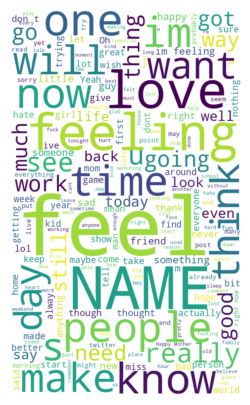

In [30]:
from wordcloud import WordCloud, STOPWORDS
# Wordcloud: text
all_text = ' '.join(df['text'])

wordcloud = WordCloud(width = 600, height = 1000, stopwords = STOPWORDS,
                      random_state = 123, background_color = 'white').generate(all_text)

fig,ax = plt.subplots(figsize = (9,5))
ax.imshow(wordcloud, cmap = 'magma', interpolation = 'bilinear')
ax.axis('off')
fig.show()

In [31]:
# LABEL ENCODING

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['label_encoded'] = encoder.fit_transform(df['label'])

df[['label', 'label_encoded']].head()

,label,label_encoded
0,sadness,5
1,sadness,5
2,neutral,4
3,sadness,5
4,sadness,5


In [32]:
# LABEL MAPPING

label_mapping = dict(zip(
    encoder.classes_,
    encoder.transform(encoder.classes_)
))

print(label_mapping)

{'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'neutral': np.int64(4), 'sadness': np.int64(5), 'surprise': np.int64(6)}


In [33]:
# ==========================================
# STEP 4: Tokenization & Sequence Padding
# ==========================================
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# 1. Features and Labels Split
X = df['clean_text']
y = df['label_encoded']

# 2. Train-Test Split (Stratified to maintain class distributions)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Hyperparameters configuration
MAX_VOCAB_SIZE = 25000  # Maximum number of unique words to keep
MAX_SEQUENCE_LENGTH = 50  # Maximum length of each tweet/text (your EDA showed a max of 40)
EMBEDDING_DIM = 128  # Dimension of the word dense embedding vectors

# 4. Tokenize text inputs
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# 5. Convert text strings to integer sequence tokens
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# 6. Pad sequences to ensure uniform input length for the neural network
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print("Training padded shape:", X_train_pad.shape)
print("Testing padded shape:", X_test_pad.shape)

Training padded shape: (55144, 50)
Testing padded shape: (13786, 50)


In [34]:
# ==========================================
# STEP 5: Build and Train the BiLSTM Network
# ==========================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping

# 1. Define Model Architecture
model = Sequential([
    # Learn word relationships in a continuous dense vector space
    Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
    SpatialDropout1D(0.3), # Dropout full 1D feature maps to promote regularization
    
    # First BiLSTM layer (returns sequences to pass to the next LSTM layer)
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    
    # Second BiLSTM layer (collapses the sequence into a single context representation)
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    
    # Fully Connected hidden layer
    Dense(64, activation='relu'),
    Dropout(0.4),
    
    # Output layer for 7 multi-class classification labels
    Dense(7, activation='softmax')
])

# 2. Compile Model
model.compile(
    loss='sparse_categorical_crossentropy', 
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), 
    metrics=['accuracy']
)

model.summary()

# 3. Add Early Stopping to stop training when validation loss stops improving
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True,
    verbose=1
)

# 4. Train the neural network
BATCH_SIZE = 64
EPOCHS = 10

history = model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,  # Uses 10% of training data for validation tracking
    callbacks=[early_stop],
    verbose=1
)

print("BiLSTM Model training completed successfully!")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 87s 102ms/step - accuracy: 0.4746 - loss: 1.4694 - val_accuracy: 0.5501 - val_loss: 1.2055
Epoch 2/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 76s 98ms/step - accuracy: 0.6597 - loss: 1.0261 - val_accuracy: 0.7084 - val_loss: 0.9283
Epoch 3/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 76s 98ms/step - accuracy: 0.7639 - loss: 0.7628 - val_accuracy: 0.7099 - val_loss: 0.9469
Epoch 4/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 78s 100ms/step - accuracy: 0.8032 - loss: 0.6317 - val_accuracy: 0.6954 - val_loss: 0.9895
Epoch 5/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 80s 102ms/step - accuracy: 0.8327 - loss: 0.5397 - val_accuracy: 0.6943 - val_loss: 1.0493
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.
BiLSTM Model training completed successfully!


431/431 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step

🚀 BiLSTM Model Accuracy: 0.7085

Classification Report:
              precision    recall  f1-score   support

       anger       0.71      0.62      0.66      1312
        fear       0.73      0.70      0.72       726
         joy       0.80      0.74      0.77      2013
        love       0.66      0.62      0.64      1465
     neutral       0.67      0.86      0.75      4883
     sadness       0.75      0.67      0.71      2603
    surprise       0.67      0.16      0.25       784

    accuracy                           0.71     13786
   macro avg       0.72      0.62      0.64     13786
weighted avg       0.71      0.71      0.70     13786



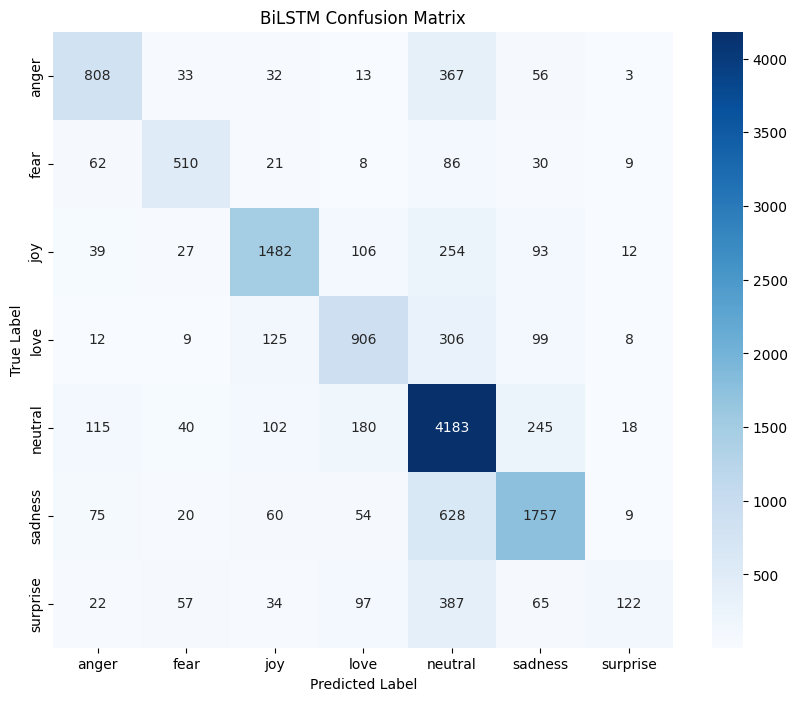

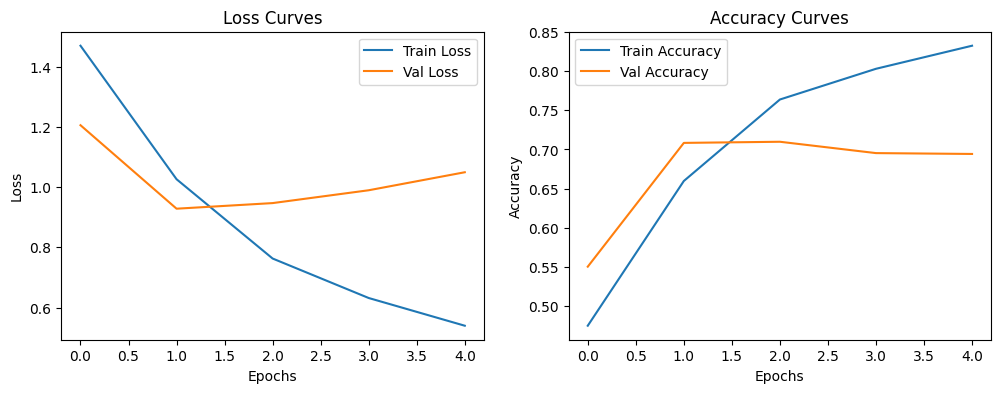

In [35]:
# ==========================================
# STEP 6: Neural Network Evaluation
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Generate model probabilities on evaluation test data
y_pred_probs = model.predict(X_test_pad)

# 2. Convert class probabilities to specific label integer mappings
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Print Final Evaluated Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🚀 BiLSTM Model Accuracy: {accuracy:.4f}\n")

# 4. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

# 5. Confusion Matrix Generating Heatmap Visualization
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)
plt.title("BiLSTM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# 6. Plot Loss Curves to check training convergence
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [36]:
import pickle

# 1. Save the Keras BiLSTM model
# Saved in the native Keras format (recommended for TensorFlow 2.x+)
model.save("bilstm_emotion_model.keras")
print("✅ BiLSTM Model saved successfully as 'bilstm_emotion_model.keras'")

# 2. Save the Tokenizer
# The tokenizer maps text strings to integers; the model cannot work without it.
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
print("✅ Tokenizer saved successfully as 'tokenizer.pkl'")

# 3. Save the Label Encoder (if you haven't already)
# This maps predicted numbers (e.g., 2) back to names (e.g., 'joy')
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)
print("✅ Label Encoder saved successfully as 'label_encoder.pkl'")

✅ BiLSTM Model saved successfully as 'bilstm_emotion_model.keras'
✅ Tokenizer saved successfully as 'tokenizer.pkl'
✅ Label Encoder saved successfully as 'label_encoder.pkl'


In [37]:
import pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Load the model and its dependencies back into memory
loaded_model = tf.keras.models.load_model("bilstm_emotion_model.keras")

with open("tokenizer.pkl", "rb") as f:
    loaded_tokenizer = pickle.load(f)

with open("label_encoder.pkl", "rb") as f:
    loaded_encoder = pickle.load(f)

print("🎉 Model, Tokenizer, and Label Encoder loaded successfully!")


# 2. Define the prediction function
def predict_emotion(raw_text, max_len=50):
    """
    Takes raw string text, processes it through the saved tokenizer/padding sequence,
    and returns the predicted emotion label along with its confidence percentage.
    """
    # Put text into a list format expected by the tokenizer
    text_sequence = loaded_tokenizer.texts_to_sequences([raw_text])
    
    # Pad the sequence exactly like we did during training
    padded_sequence = pad_sequences(text_sequence, maxlen=max_len, padding='post', truncating='post')
    
    # Make prediction (returns probabilities for each class)
    probabilities = loaded_model.predict(padded_sequence, verbose=0)[0]
    
    # Get index of the highest probability
    predicted_class_idx = np.argmax(probabilities)
    
    # Map index back to string label
    predicted_emotion = loaded_encoder.inverse_transform([predicted_class_idx])[0]
    confidence = probabilities[predicted_class_idx] * 100
    
    return predicted_emotion, confidence


# ==========================================================
# 3. Test your own custom inputs!
# ==========================================================
test_sentences = [
    "I can't believe I finally passed my engineering exam, I am over the moon!",
    "It feels like everything is falling apart and nothing I do matters anymore.",
    "Be careful when driving down that dark road late at night, it's dangerous.",
    "Oh wow, I absolutely did not see that twist coming at the end of the movie!",
    "The package arrived on Tuesday afternoon as scheduled."
]

print("\n--- Model Testing Results ---")
for sentence in test_sentences:
    emotion, conf = predict_emotion(sentence)
    print(f"Text: \"{sentence}\"")
    print(f"🔮 Predicted Emotion: {emotion.upper()} ({conf:.2f}% confidence)\n")

🎉 Model, Tokenizer, and Label Encoder loaded successfully!

--- Model Testing Results ---
Text: "I can't believe I finally passed my engineering exam, I am over the moon!"
🔮 Predicted Emotion: FEAR (34.88% confidence)

Text: "It feels like everything is falling apart and nothing I do matters anymore."
🔮 Predicted Emotion: NEUTRAL (32.92% confidence)

Text: "Be careful when driving down that dark road late at night, it's dangerous."
🔮 Predicted Emotion: ANGER (45.64% confidence)

Text: "Oh wow, I absolutely did not see that twist coming at the end of the movie!"
🔮 Predicted Emotion: SURPRISE (37.01% confidence)

Text: "The package arrived on Tuesday afternoon as scheduled."
🔮 Predicted Emotion: NEUTRAL (59.29% confidence)



In [38]:
print("Type 'exit' or 'quit' to stop the loop.\n")

while True:
    user_input = input("Enter a sentence to detect emotion: ")
    if user_input.lower() in ['exit', 'quit']:
        print("Loop terminated.")
        break
    
    if user_input.strip() == "":
        continue
        
    emotion, conf = predict_emotion(user_input)
    print(f"➡️ Detected Emotion: {emotion.upper()} | Confidence: {conf:.2f}%\n")

Type 'exit' or 'quit' to stop the loop.



Enter a sentence to detect emotion:  hello bay i love you


➡️ Detected Emotion: LOVE | Confidence: 71.13%



Enter a sentence to detect emotion:  exit


Loop terminated.
